##Q1. Which dataset have you selected for your project?

I have selected the Toyota Cars Dataset, which contains listings of different Toyota models along with 
their key specifications.

##Q2. Briefly describe the contents and purpose of your dataset.


The dataset includes details about various Toyota vehicles. It has fields such as model, year, price, 
mileage, fuel type, transmission, tax, miles per gallon and engine size.

The purpose of the dataset is to understand trends in the used car market. It helps show how factors 
like year, mileage and engine size affect price. It can also highlight which models are more common, 
how fuel types vary across listings and how car features have changed over time.

##Q3. What type of data analysis do you plan to perform using this dataset?


I plan to perform data cleaning, exploratory data analysis and visualization using Pandas and Matplotlib.





#CODE

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("toyota (1).csv")

print(df.head())

   model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   GT86  2016  16000       Manual    24089   Petrol  265  36.2         2.0
1   GT86  2017  15995       Manual    18615   Petrol  145  36.2         2.0
2   GT86  2015  13998       Manual    27469   Petrol  265  36.2         2.0
3   GT86  2017  18998       Manual    14736   Petrol  150  36.2         2.0
4   GT86  2017  17498       Manual    36284   Petrol  145  36.2         2.0


In [4]:
print(df.shape)


(6738, 9)


In [5]:
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6738 entries, 0 to 6737
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         6738 non-null   object 
 1   year          6738 non-null   int64  
 2   price         6738 non-null   int64  
 3   transmission  6738 non-null   object 
 4   mileage       6738 non-null   int64  
 5   fuelType      6738 non-null   object 
 6   tax           6738 non-null   int64  
 7   mpg           6738 non-null   float64
 8   engineSize    6738 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 473.9+ KB
None


In [6]:
print(df.describe())

              year         price        mileage          tax          mpg  \
count  6738.000000   6738.000000    6738.000000  6738.000000  6738.000000   
mean   2016.748145  12522.391066   22857.413921    94.697240    63.042223   
std       2.204062   6345.017587   19125.464147    73.880776    15.836710   
min    1998.000000    850.000000       2.000000     0.000000     2.800000   
25%    2016.000000   8290.000000    9446.000000     0.000000    55.400000   
50%    2017.000000  10795.000000   18513.000000   135.000000    62.800000   
75%    2018.000000  14995.000000   31063.750000   145.000000    69.000000   
max    2020.000000  59995.000000  174419.000000   565.000000   235.000000   

        engineSize  
count  6738.000000  
mean      1.471297  
std       0.436159  
min       0.000000  
25%       1.000000  
50%       1.500000  
75%       1.800000  
max       4.500000  


In [7]:
# CLEAN MISSING VALUES

print("Missing:\n", df.isnull().sum())

Missing:
 model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


In [10]:
df = df.dropna()


In [11]:
df = df.drop_duplicates()

print("Cleaned shape:", df.shape)




Cleaned shape: (6699, 9)


In [12]:
# FEATURE ENGINEERING


# . Car age
df["car_age"] = 2025 - df["year"]


In [13]:
# . Price per mile
df["price_per_mile"] = df["price"] / df["mileage"].replace(0, pd.NA)



In [14]:
# . Mileage per year
df["mileage_per_year"] = df["mileage"] / df["car_age"]



In [15]:
# . Price rank
df = df.sort_values("price")
df["price_rank"] = range(1, len(df) + 1)



In [16]:
# . Group average price by model 
avg_price_by_model = df.groupby("model")["price"].mean()



In [18]:
# . Engine category counts
engine_counts = df["engineSize"].value_counts()

print("\nAverage price by model:\n", avg_price_by_model)
print("\nEngine category counts:\n", engine_counts)




Average price by model:
 model
Auris            12524.730606
Avensis           9878.122807
Aygo              7887.239175
C-HR             20651.540710
Camry            26910.090909
Corolla          20972.675472
GT86             19908.849315
Hilux            21581.176471
IQ                4247.250000
Land Cruiser     36487.156863
PROACE VERSO     28680.200000
Prius            18998.844828
RAV4             18200.421842
Supra            50741.000000
Urban Cruiser     4617.500000
Verso            12169.157895
Verso-S           5746.666667
Yaris            10548.840340
Name: price, dtype: float64

Engine category counts:
 engineSize
1.0    2038
1.5    1419
1.8    1289
1.3     600
2.0     394
1.2     300
2.5     247
1.6     166
2.4      70
2.2      58
1.4      40
2.8      36
3.0      34
0.0       6
4.2       1
4.5       1
Name: count, dtype: int64


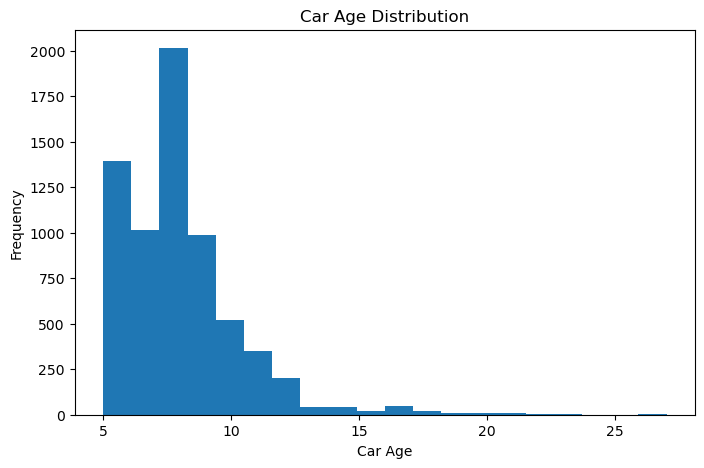

In [19]:
# VISUALIZATIONS


# Car age distribution
plt.figure(figsize=(8, 5))
plt.hist(df["car_age"], bins=20)
plt.xlabel("Car Age")
plt.ylabel("Frequency")
plt.title("Car Age Distribution")
plt.show()

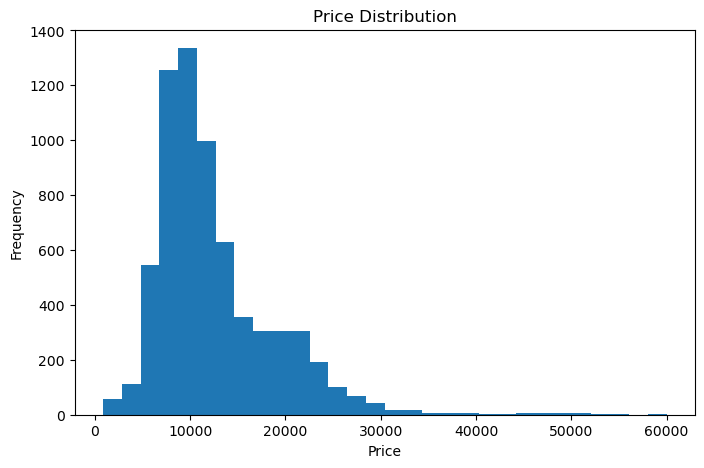

In [20]:
# Price distribution
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=30)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")
plt.show()



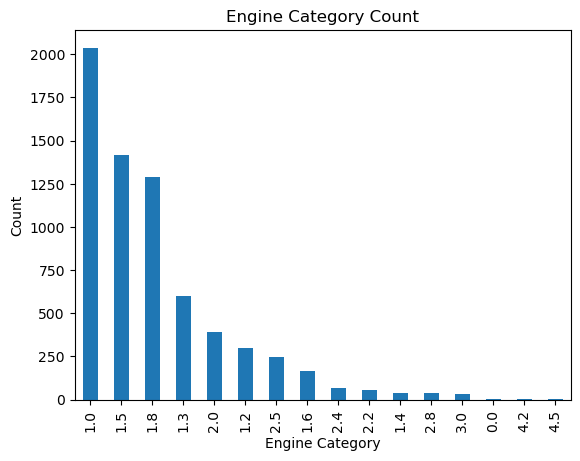

In [32]:
# Engine category bar chart
df["engineSize"].value_counts().plot(kind="bar")
plt.xlabel("Engine Category")
plt.ylabel("Count")
plt.title("Engine Category Count")
plt.show()



In [ ]:
# Mileage band bar chart
df["mileage_band"] = df["mileage"].astype(str)

df["mileage_band"].value_counts().plot(kind="bar")
plt.xlabel("Mileage Band")
plt.ylabel("Count")
plt.title("Mileage Band Distribution")
plt.show()